Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

Load the Dataset

In [5]:
df = pd.read_csv("judge-1377884607_tweet_product_company.csv", encoding='latin-1')
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [9]:
print(df.columns)

Index(['tweet_text', 'emotion_in_tweet_is_directed_at',
       'is_there_an_emotion_directed_at_a_brand_or_product'],
      dtype='object')


Data Preprocessing

Select Required Columns & Remove Null Values

In [11]:
df = df[['tweet_text', 'is_there_an_emotion_directed_at_a_brand_or_product']].copy()
df = df.dropna()

clean text data

In [13]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)   # remove URLs
    text = re.sub(r"[^a-zA-Z ]", "", text)  # remove special characters
    return text

df['clean_tweet'] = df['tweet_text'].apply(clean_text)

encode target labeles

In [14]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['is_there_an_emotion_directed_at_a_brand_or_product'])

df[['clean_tweet','label']].head()

,clean_tweet,label
0,wesley i have a g iphone after hrs tweeting a...,1
1,jessedee know about fludapp awesome ipadiphon...,3
2,swonderlin can not wait for ipad also they sh...,3
3,sxsw i hope this years festival isnt as crashy...,1
4,sxtxstate great stuff on fri sxsw marissa maye...,3


split the dataset

In [15]:
X = df['clean_tweet']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Tokenization and Padding

In [16]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=50)
X_test_pad = pad_sequences(X_test_seq, maxlen=50)

build LSTM model

In [18]:
model = Sequential()

model.add(Embedding(input_dim=5000, output_dim=64, input_length=50))
model.add(LSTM(64))
model.add(Dense(4, activation='softmax'))  # 4 classes

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

C:\Users\akash\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

train the model

In [19]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.6029 - loss: 0.9053 - val_accuracy: 0.6119 - val_loss: 0.8544
Epoch 2/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7008 - loss: 0.7285 - val_accuracy: 0.6449 - val_loss: 0.8192
Epoch 3/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7705 - loss: 0.5767 - val_accuracy: 0.6575 - val_loss: 0.8096
Epoch 4/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8118 - loss: 0.4850 - val_accuracy: 0.6630 - val_loss: 0.8982
Epoch 5/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8387 - loss: 0.4194 - val_accuracy: 0.6701 - val_loss: 0.9331


Evaluate the Model

In [20]:
loss, accuracy = model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", accuracy)

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6701 - loss: 0.9331 
Test Accuracy: 0.6701484322547913


Plot Accuracy Graph

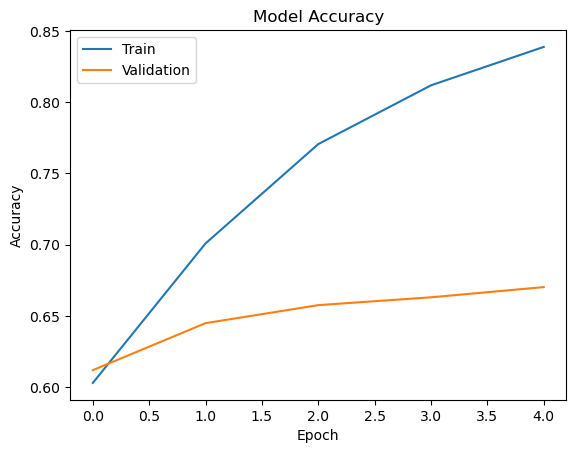

In [21]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

Test with New Input